# Models evaluator notebook  

## Load and prepare data

In [459]:
import json
import os
import pandas as pd

In [460]:
# Read all JSON files from the specified directory
outputs_path = '/Users/sofi/Desktop/CollectiveAI/projects/data-genero/backend/resources/data/sample/'
json_files = [f for f in os.listdir(outputs_path) if f.endswith('.json')]
json_files

['anonymization_paragraph.json',
 'anonymization_document_paragraph-doc06.json',
 'anonymization_document-doc06.json',
 'anonymization_document.json',
 'anonymization_document_paragraph.json',
 'annotations.json',
 'anonymization_paragraph-doc06.json']

### Exploratory 

In [461]:
doc_df = pd.concat([
    pd.read_json(outputs_path + 'anonymization_document-doc06.json'),
    pd.read_json(outputs_path + 'anonymization_document.json')
])
doc_df.head(2)


,id,created_at,updated_at,name
0,f8761c56b39b5a6387367266f7c67bae,2025-08-12 20:39:26-03:00,NaT,5188_57_20_01_2023_149bis CAUSA 4671_2023.docx
1,4da9843514255b96b1090ad5dd685144,2025-08-24 18:44:21-03:00,NaT,document-06.docx


In [462]:
doc_para_df = pd.concat([
    pd.read_json(outputs_path + 'anonymization_document_paragraph-doc06.json'),
    pd.read_json(outputs_path + 'anonymization_document_paragraph.json')])
doc_para_df.head

<bound method NDFrame.head of                                   id                       document_id  \
0   f8e779753ed54f62b71cb0033d2dceff  f8761c56b39b5a6387367266f7c67bae   
1   f98629e4b8bf4f09801c1563ae0cdcec  f8761c56b39b5a6387367266f7c67bae   
2   087aca489e47468fa4fce332248c3dd7  f8761c56b39b5a6387367266f7c67bae   
3   e51935f992bf4c55a3ce541b3f96787a  f8761c56b39b5a6387367266f7c67bae   
4   e8ce401964d0415db128c1eedbf1a54e  f8761c56b39b5a6387367266f7c67bae   
..                               ...                               ...   
95  60089cc2d5954e4c807bfa8feea56e4a  da0791b5cfb7552697d151574d2e7a09   
96  87422dbccbc24861937009924a18e2aa  da0791b5cfb7552697d151574d2e7a09   
97  15a37f44f66a4c5d920a12c355bf7dd0  da0791b5cfb7552697d151574d2e7a09   
98  38e1d7f168ab46fa9dd269f46c519f4b  da0791b5cfb7552697d151574d2e7a09   
99  bb81b6061c3d4a89a1d94d5ef6956ead  da0791b5cfb7552697d151574d2e7a09   

                        paragraph_id  order  
0   59dc7264d5845c30b01d3de2de4df1f

In [463]:
merged_df = pd.merge(
    doc_para_df,
    doc_df[['id', 'created_at', 'name']],
    left_on='document_id',
    right_on='id',
    how='left'
)
merged_df = merged_df.rename(columns={'id_x': 'par_id'}).drop(columns=['id_y'])
merged_df.head(2)

,par_id,document_id,paragraph_id,order,created_at,name
0,f8e779753ed54f62b71cb0033d2dceff,f8761c56b39b5a6387367266f7c67bae,59dc7264d5845c30b01d3de2de4df1fa,NaN,2025-08-12 20:39:26-03:00,5188_57_20_01_2023_149bis CAUSA 4671_2023.docx
1,f98629e4b8bf4f09801c1563ae0cdcec,f8761c56b39b5a6387367266f7c67bae,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-12 20:39:26-03:00,5188_57_20_01_2023_149bis CAUSA 4671_2023.docx


In [464]:
para_df = pd.concat([
    pd.read_json(outputs_path + 'anonymization_paragraph-doc06.json'),
    pd.read_json(outputs_path + 'anonymization_paragraph.json')])
para_df.head(3)

,text,prediction,validation,id,created_at,updated_at
0,Acusado: Ramiro Marrón DNI 34.555.666.,"[{""start"": 1, ""end"": 3, ""label"": ""PER"", ""text""...",null,735e0ac6ee97548aab5402e61fc6487c,2025-07-22 02:20:28-03:00,NaT
1,1983-2023. 40 Años de Democracia,[],[],59dc7264d5845c30b01d3de2de4df1fa,2025-08-12 20:37:32-03:00,2025-08-12 20:39:26-03:00
2,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-12 20:37:32-03:00,2025-08-12 20:39:26-03:00


In [465]:
df = pd.merge(
    para_df,
    merged_df,
    left_on='id',
    right_on='paragraph_id',
    how='left'
)
#merged_df = merged_df.rename(columns={'id_x': 'id'}).drop(columns=['id_y'])
df.head(10)

,text,prediction,validation,id,created_at_x,updated_at,par_id,document_id,paragraph_id,order,created_at_y,name
0,Acusado: Ramiro Marrón DNI 34.555.666.,"[{""start"": 1, ""end"": 3, ""label"": ""PER"", ""text""...",null,735e0ac6ee97548aab5402e61fc6487c,2025-07-22 02:20:28-03:00,NaT,NaN,NaN,NaN,NaN,NaT,NaN
1,1983-2023. 40 Años de Democracia,[],[],59dc7264d5845c30b01d3de2de4df1fa,2025-08-12 20:37:32-03:00,2025-08-12 20:39:26-03:00,f8e779753ed54f62b71cb0033d2dceff,f8761c56b39b5a6387367266f7c67bae,59dc7264d5845c30b01d3de2de4df1fa,NaN,2025-08-12 20:39:26-03:00,5188_57_20_01_2023_149bis CAUSA 4671_2023.docx
2,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-12 20:37:32-03:00,2025-08-12 20:39:26-03:00,f98629e4b8bf4f09801c1563ae0cdcec,f8761c56b39b5a6387367266f7c67bae,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-12 20:39:26-03:00,5188_57_20_01_2023_149bis CAUSA 4671_2023.docx
3,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-12 20:37:32-03:00,2025-08-12 20:39:26-03:00,5e6e2c92735c4d52a54cd9aa6365d00e,06918bd1795951b686d880d48f757e6b,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-08 19:40:46-03:00,7719_84_25_04_2025_128 CAUSA 108848_2024.docx
4,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-12 20:37:32-03:00,2025-08-12 20:39:26-03:00,5fdfb0c683a74bea92e261f82b7836e2,da0791b5cfb7552697d151574d2e7a09,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-22 19:09:05-03:00,document-09.docx
5,"TELIAS, PABLO MARTIN SOBRE 149 BIS - AMENAZAS","[{""start"": 0, ""end"": 3, ""label"": ""PER"", ""text""...","[{""text"": ""TELIAS, PABLO MARTIN"", ""start_char""...",a728442cf12a51ddb2d4b42c1d97b002,2025-08-12 20:37:33-03:00,2025-08-12 20:39:26-03:00,087aca489e47468fa4fce332248c3dd7,f8761c56b39b5a6387367266f7c67bae,a728442cf12a51ddb2d4b42c1d97b002,NaN,2025-08-12 20:39:26-03:00,5188_57_20_01_2023_149bis CAUSA 4671_2023.docx
6,Número: IPP 1234/2023-0,"[{""start"": 1, ""end"": 3, ""label"": ""NUM_EXPEDIEN...","[{""text"": ""IPP 1234/2023-0"", ""start_char"": 8, ...",a76fa4cb055c5abe9116330762c71b92,2025-08-12 20:37:33-03:00,2025-08-12 20:39:26-03:00,e51935f992bf4c55a3ce541b3f96787a,f8761c56b39b5a6387367266f7c67bae,a76fa4cb055c5abe9116330762c71b92,NaN,2025-08-12 20:39:26-03:00,5188_57_20_01_2023_149bis CAUSA 4671_2023.docx
7,Actuación Nro: 22233/2023,"[{""start"": 2, ""end"": 3, ""label"": ""NUM_ACTUACIO...","[{""text"": ""22233/2023"", ""start_char"": 15, ""end...",d12b16a0c8e354109c5087b1287a35aa,2025-08-12 20:37:38-03:00,2025-08-12 20:39:26-03:00,90d4dfda98e74450a3fe91f3b541a318,f8761c56b39b5a6387367266f7c67bae,d12b16a0c8e354109c5087b1287a35aa,NaN,2025-08-12 20:39:26-03:00,5188_57_20_01_2023_149bis CAUSA 4671_2023.docx
8,CUIJ: IPP J-01-00001234-6/2023-0,"[{""start"": 1, ""end"": 3, ""label"": ""CUIJ"", ""text...","[{""text"": ""IPP J-01-00001234-6/2023-0"", ""start...",76b4b01704975fc2a40f5bfa41890242,2025-08-12 20:37:38-03:00,2025-08-12 20:39:26-03:00,e8ce401964d0415db128c1eedbf1a54e,f8761c56b39b5a6387367266f7c67bae,76b4b01704975fc2a40f5bfa41890242,NaN,2025-08-12 20:39:26-03:00,5188_57_20_01_2023_149bis CAUSA 4671_2023.docx
9,AUDIENCIA CON LA VÍCTIMA,[],[],9ce24ca96fb3541c84433f5740594076,2025-08-12 20:37:38-03:00,2025-08-12 20:39:26-03:00,4dd451ea78fc4e059e3ee2eb9e6c9a7d,f8761c56b39b5a6387367266f7c67bae,9ce24ca96fb3541c84433f5740594076,NaN,2025-08-12 20:39:26-03:00,5188_57_20_01_2023_149bis CAUSA 4671_2023.docx


### Generalized load for multiple json files:

In [466]:
doc_df

,id,created_at,updated_at,name
0,f8761c56b39b5a6387367266f7c67bae,2025-08-12 20:39:26-03:00,NaT,5188_57_20_01_2023_149bis CAUSA 4671_2023.docx
1,4da9843514255b96b1090ad5dd685144,2025-08-24 18:44:21-03:00,NaT,document-06.docx
0,06918bd1795951b686d880d48f757e6b,2025-08-08 19:40:46-03:00,NaT,7719_84_25_04_2025_128 CAUSA 108848_2024.docx
1,abe7fa68a5c35e7f81e76167a7c23db6,2025-08-08 19:42:15-03:00,NaT,Comprobante de transferencia - 18-12-2024.pdf
2,da0791b5cfb7552697d151574d2e7a09,2025-08-22 19:09:05-03:00,NaT,document-09.docx
3,0aec75365ad0511698f72bacb8b88212,2025-08-22 19:41:55-03:00,NaT,document-03.docx
4,9dfa3cb436a85f6fba380b1d82e711b8,2025-08-22 20:51:16-03:00,NaT,document-07.docx
5,518a7f34ad865b91ad95d954093f091a,2025-08-22 21:20:53-03:00,NaT,document-02.docx


In [467]:
doc_para_files

['anonymization_document_paragraph-doc06.json',
 'anonymization_document_paragraph.json']

In [468]:
para_files = [f for f in json_files if f.startswith('anonymization_paragraph')]
para_df = pd.concat([pd.read_json(outputs_path + fname) for fname in para_files], ignore_index=True)

doc_files = [f for f in json_files if f.startswith('anonymization_document') and not 'paragraph' in f]
doc_df = pd.concat([pd.read_json(outputs_path + fname) for fname in doc_files], ignore_index=True)

doc_para_files = [f for f in json_files if f.startswith('anonymization_document_paragraph')]
doc_para_df = pd.concat([pd.read_json(outputs_path + fname) for fname in doc_para_files], ignore_index=True)

doc_df = doc_df.copy()
doc_para_df = doc_para_df.copy()
doc_df['id'] = doc_df['id'].astype(str)
doc_para_df['document_id'] = doc_para_df['document_id'].astype(str)


merged_df = pd.merge(
    doc_para_df,
    doc_df[['id', 'created_at', 'name']],
    left_on='document_id',
    right_on='id',
    how='left'
).rename(columns={'id_x': 'id'}).drop(columns=['id_y'])

df = pd.merge(
    para_df,
    merged_df,
    left_on='id',
    right_on='paragraph_id',
    how='left'
)

df.head(5)

,text,prediction,validation,id_x,created_at_x,updated_at,id_y,document_id,paragraph_id,order,created_at_y,name
0,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-08 19:39:59-03:00,2025-08-08 19:40:45-03:00,f98629e4b8bf4f09801c1563ae0cdcec,f8761c56b39b5a6387367266f7c67bae,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-12 20:39:26-03:00,5188_57_20_01_2023_149bis CAUSA 4671_2023.docx
1,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-08 19:39:59-03:00,2025-08-08 19:40:45-03:00,5e6e2c92735c4d52a54cd9aa6365d00e,06918bd1795951b686d880d48f757e6b,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-08 19:40:46-03:00,7719_84_25_04_2025_128 CAUSA 108848_2024.docx
2,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-08 19:39:59-03:00,2025-08-08 19:40:45-03:00,5fdfb0c683a74bea92e261f82b7836e2,da0791b5cfb7552697d151574d2e7a09,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-22 19:09:05-03:00,document-09.docx
3,Número: IPP 108848/2024-0,"[{""start"": 1, ""end"": 3, ""label"": ""NUM_EXPEDIEN...","[{""text"": ""IPP 108848/2024-0"", ""start_char"": 8...",39cf47ba6524537dba1d5df91ab0d160,2025-08-08 19:39:59-03:00,2025-08-08 19:40:45-03:00,128227b9bf6248fcbd9b2c5c76b34631,06918bd1795951b686d880d48f757e6b,39cf47ba6524537dba1d5df91ab0d160,NaN,2025-08-08 19:40:46-03:00,7719_84_25_04_2025_128 CAUSA 108848_2024.docx
4,CUIJ: IPP J-01-00108848-9/2024-0,"[{""start"": 1, ""end"": 3, ""label"": ""CUIJ"", ""text...","[{""text"": ""IPP J-01-00108848-9/2024-0"", ""start...",bef42849c3b8580ca49a8b42de2baf44,2025-08-08 19:40:00-03:00,2025-08-08 19:40:45-03:00,1d31279a67d74e85adeee085f0fd50fe,06918bd1795951b686d880d48f757e6b,bef42849c3b8580ca49a8b42de2baf44,NaN,2025-08-08 19:40:46-03:00,7719_84_25_04_2025_128 CAUSA 108848_2024.docx


In [469]:
doc_para_df[doc_para_df['document_id']=='0aec75365ad0511698f72bacb8b88212']

,id,document_id,paragraph_id,order


In [470]:
doc_df

,id,created_at,updated_at,name
0,f8761c56b39b5a6387367266f7c67bae,2025-08-12 20:39:26-03:00,NaT,5188_57_20_01_2023_149bis CAUSA 4671_2023.docx
1,4da9843514255b96b1090ad5dd685144,2025-08-24 18:44:21-03:00,NaT,document-06.docx
2,06918bd1795951b686d880d48f757e6b,2025-08-08 19:40:46-03:00,NaT,7719_84_25_04_2025_128 CAUSA 108848_2024.docx
3,abe7fa68a5c35e7f81e76167a7c23db6,2025-08-08 19:42:15-03:00,NaT,Comprobante de transferencia - 18-12-2024.pdf
4,da0791b5cfb7552697d151574d2e7a09,2025-08-22 19:09:05-03:00,NaT,document-09.docx
5,0aec75365ad0511698f72bacb8b88212,2025-08-22 19:41:55-03:00,NaT,document-03.docx
6,9dfa3cb436a85f6fba380b1d82e711b8,2025-08-22 20:51:16-03:00,NaT,document-07.docx
7,518a7f34ad865b91ad95d954093f091a,2025-08-22 21:20:53-03:00,NaT,document-02.docx


In [471]:
para_df

,text,prediction,validation,id,created_at,updated_at
0,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-08 19:39:59-03:00,2025-08-08 19:40:45-03:00
1,Número: IPP 108848/2024-0,"[{""start"": 1, ""end"": 3, ""label"": ""NUM_EXPEDIEN...","[{""text"": ""IPP 108848/2024-0"", ""start_char"": 8...",39cf47ba6524537dba1d5df91ab0d160,2025-08-08 19:39:59-03:00,2025-08-08 19:40:45-03:00
2,CUIJ: IPP J-01-00108848-9/2024-0,"[{""start"": 1, ""end"": 3, ""label"": ""CUIJ"", ""text...","[{""text"": ""IPP J-01-00108848-9/2024-0"", ""start...",bef42849c3b8580ca49a8b42de2baf44,2025-08-08 19:40:00-03:00,2025-08-08 19:40:45-03:00
3,Actuación Nro: 659483/2025,"[{""start"": 2, ""end"": 3, ""label"": ""NUM_ACTUACIO...","[{""text"": ""659483/2025"", ""start_char"": 15, ""en...",72e32ada6afd558c8eeef1783281988e,2025-08-08 19:40:00-03:00,2025-08-08 19:40:45-03:00
4,"AYALA, FERNANDO GABRIEL SOBRE 128 1 párr - Mat...","[{""start"": 0, ""end"": 3, ""label"": ""PER"", ""text""...","[{""text"": ""AYALA, FERNANDO GABRIEL"", ""start_ch...",0cdfc52a194e585486cb82ef42cdd4ac,2025-08-08 19:40:00-03:00,2025-08-08 19:40:45-03:00
...,...,...,...,...,...,...
395,Juez: le hace saber que eso es justamente lo q...,[],[],472de64b3e47587b98ba7562a4852c31,2025-08-17 19:57:26-03:00,2025-08-24 18:44:20-03:00
396,"Luego del egreso de la víctima, dispone el ing...","[{""start"": 16, ""end"": 17, ""label"": ""PER"", ""tex...","[{""text"": ""GONZALEZ"", ""start_char"": 85, ""end_c...",972b40afa2115a4daa478e6004a875be,2025-08-17 19:57:26-03:00,2025-08-24 18:44:20-03:00
397,Juez: le agradece su comparecencia y le hace s...,[],[],d3f5cc9ad3415c4d8723df79fd13dbcd,2025-08-17 19:57:26-03:00,2025-08-24 18:44:20-03:00
398,Juez: cede la palabra a la Fiscalía para que f...,[],[],8e2015cdcbd25740b92ee2582b9696e4,2025-08-17 19:57:27-03:00,2025-08-24 18:44:20-03:00


In [472]:
doc_para_df[doc_para_df['document_id']=='4da9843514255b96b1090ad5dd685144']

,id,document_id,paragraph_id,order
30,efdd1973531e4bde8a40a2c2f32ff5d3,4da9843514255b96b1090ad5dd685144,45b5531cdc7c5f7c9aaaca30e8b779a4,NaN
31,4d228428dfa84bf584de4d1d212ebb14,4da9843514255b96b1090ad5dd685144,561f1f20e55d5ad1b8ef64340d08c7f4,NaN
32,fdd5365509de460d87c2349a44e08e61,4da9843514255b96b1090ad5dd685144,7009436c451d52c2b5090e8e252b690e,NaN
33,0ce4f7bf96f546dba2804f3df31774e4,4da9843514255b96b1090ad5dd685144,1b20a1be99cb5c4684f16cf1f70cf5b6,NaN
34,62896258fd0f4819bb926468b022f4c5,4da9843514255b96b1090ad5dd685144,f44b4abccf09563b9b6e263551ba938a,NaN
...,...,...,...,...
95,d9f1854fb4b04489ab1fa2faddd538d0,4da9843514255b96b1090ad5dd685144,472de64b3e47587b98ba7562a4852c31,NaN
96,f7729d91557a41509a95264beaca6bb5,4da9843514255b96b1090ad5dd685144,972b40afa2115a4daa478e6004a875be,NaN
97,068878028ddc41bf97e48a906ad6453a,4da9843514255b96b1090ad5dd685144,394cad2cd77353e994ae05ed071f915c,NaN
98,eb87626c01cb477d91805b45d252d534,4da9843514255b96b1090ad5dd685144,8e2015cdcbd25740b92ee2582b9696e4,NaN


In [473]:
def metrics_for_label(df, target = 'text'):
    tp, fp, fn = 0, 0, 0
    for i in range(len(df)):
        try:
            val = eval(df.validation.iloc[i])[0]
        except:
            val = []
        try:
            pred = eval(df.prediction.iloc[i])[0]
        except:
            pred = []
        
        if target == 'text':
            text_val = val.get('attrs',None).get('aymurai_alt_text',None) if val else None
            text_pred= pred.get('text',None) if pred else None
            pred_set = set((text_pred,))
            val_set = set((text_val,))

        elif target == 'label':
            label_pred= pred.get('label',None) if pred else None
            label_val= val.get('attrs',None).get('aymurai_label',None) if val else None
            pred_set = set((label_pred,))
            val_set = set((label_val,))

        elif target == 'both':
            text_val = val.get('attrs',None).get('aymurai_alt_text',None) if val else None
            text_pred= pred.get('text',None) if pred else None
            label_pred= pred.get('label',None) if pred else None
            label_val= val.get('attrs',None).get('aymurai_label',None) if val else None
            pred_set = set((text_pred, label_pred))
            val_set = set((text_val, label_val))

        else:
            raise ValueError("Target must be one of 'text', 'label', or 'both'")
        if len(pred_set)>0 or len(val_set)>0: 
            tp += len(pred_set & val_set)
            fp += len(pred_set - val_set)
            fn += len(val_set - pred_set)

    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / ( tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (recall + precision) > 0 else 0

    return {'recall': recall, 'precision': precision, 'f1': f1}


In [474]:
def metrics_for_label(df, target = 'text'):
    tp, fp, fn = 0, 0, 0
    for i in range(len(df)):
        try:
            val = eval(df.validation.iloc[i])[0]
        except:
            val = []
        try:
            pred = eval(df.prediction.iloc[i])[0]
        except:
            pred = []
        
        if target == 'text':
            text_val = val.get('attrs',None).get('aymurai_alt_text',None) if val else None
            text_pred= pred.get('text',None) if pred else None
            pred_set = set((text_pred,))
            val_set = set((text_val,))

        elif target == 'label':
            label_pred= pred.get('label',None) if pred else None
            label_val= val.get('attrs',None).get('aymurai_label',None) if val else None
            pred_set = set((label_pred,))
            val_set = set((label_val,))

        elif target == 'both':
            text_val = val.get('attrs',None).get('aymurai_alt_text',None) if val else None
            text_pred= pred.get('text',None) if pred else None
            label_pred= pred.get('label',None) if pred else None
            label_val= val.get('attrs',None).get('aymurai_label',None) if val else None
            pred_set = set((text_pred, label_pred))
            val_set = set((text_val, label_val))

        else:
            raise ValueError("Target must be one of 'text', 'label', or 'both'")
        if len(pred_set)>0 or len(val_set)>0: 
            tp += len(pred_set & val_set)
            fp += len(pred_set - val_set)
            fn += len(val_set - pred_set)

    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / ( tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (recall + precision) > 0 else 0

    return {'recall': recall, 'precision': precision, 'f1': f1}


In [475]:
df_main.name.unique()

array(['document-09.docx', 'document-06.docx'], dtype=object)

In [476]:
# TN es importante pero no cuenta en precision/recall/f1

In [484]:
eval(df.prediction.iloc[i])

[{'start': 1,
  'end': 3,
  'label': 'NUM_EXPEDIENTE',
  'text': 'IPP 108848/2024-0',
  'start_char': 8,
  'end_char': 25,
  'context_pre': 'Número:',
  'context_post': '',
  'attrs': {'aymurai_label': 'NUM_EXPEDIENTE',
   'aymurai_label_subclass': [],
   'aymurai_alt_text': 'IPP 108848/2024-0',
   'aymurai_alt_start_char': 8,
   'aymurai_alt_end_char': 25,
   'aymurai_method': 'ner/flair',
   'aymurai_score': 0.9999329447746277}}]

### Test

In [485]:
from collections import defaultdict

def metrics_per_entity_by_span(df):
    # acumula TP/FP/FN por entidad (label)
    counts = defaultdict(lambda: {'tp': 0, 'fp': 0, 'fn': 0})

    for i in range(len(df)):
        # cada celda puede ser una lista de dicts; si falla, lista vacía
        try:
            val_list = eval(df.validation.iloc[i])
        except:
            val_list = []
        try:
            pred_list = eval(df.prediction.iloc[i])
        except:
            pred_list = []
            
        # sets de spans por label: {(start, end), ...}
        val_spans = defaultdict(set)
        pred_spans = defaultdict(set)

        # VALIDATION (val)
        for v in (val_list or []):
            if not isinstance(v, dict):
                continue
            lab = (v.get('attrs', {}).get('aymurai_label', None)) or v.get('label', None)
            s = v.get('attrs', {}).get('aymurai_alt_start_char', None)
            e = v.get('attrs', {}).get('aymurai_alt_end_char', None)
            if lab is not None and s is not None and e is not None:
                val_spans[lab].add((int(s), int(e)))
                print('validation:')
                print(lab, s, e)

        # PREDICTIONS
        for p in (pred_list or []):
            if not isinstance(p, dict):
                continue
            lab = (p.get('attrs', {}).get('aymurai_label', None)) or p.get('label', None)
            s = p.get('attrs', {}).get('aymurai_alt_start_char', None)
            e = p.get('attrs', {}).get('aymurai_alt_end_char', None)
            if lab is not None and s is not None and e is not None:
                pred_spans[lab].add((int(s), int(e)))
                print('prediction:')
                print(lab, s, e)

        # actualizar TP/FP/FN por label en esta fila
        for lab in set(list(val_spans.keys()) + list(pred_spans.keys())):
            vs = val_spans.get(lab, set())
            ps = pred_spans.get(lab, set())
            tp = len(ps & vs)
            fp = len(ps - vs)
            fn = len(vs - ps)
            counts[lab]['tp'] += tp
            counts[lab]['fp'] += fp
            counts[lab]['fn'] += fn

    # calcular métricas por label + micro/macro
    out = {'per_label': {}, 'micro': {}, 'macro': {}}
    micro_tp = micro_fp = micro_fn = 0

    for lab, c in counts.items():
        tp, fp, fn = c['tp'], c['fp'], c['fn']
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        support   = tp + fn  # cantidad de entidades de referencia (validation) para ese label
        out['per_label'][lab] = {'precision': precision, 'recall': recall, 'f1': f1, 'support': support}
        micro_tp += tp; micro_fp += fp; micro_fn += fn

    # micro
    micro_p = micro_tp / (micro_tp + micro_fp) if (micro_tp + micro_fp) > 0 else 0.0
    micro_r = micro_tp / (micro_tp + micro_fn) if (micro_tp + micro_fn) > 0 else 0.0
    micro_f = 2 * micro_p * micro_r / (micro_p + micro_r) if (micro_p + micro_r) > 0 else 0.0
    out['micro'] = {'precision': micro_p, 'recall': micro_r, 'f1': micro_f, 'support': micro_tp + micro_fn}

    # macro (promedio simple entre labels presentes)
    if out['per_label']:
        L = len(out['per_label'])
        macro_p = sum(m['precision'] for m in out['per_label'].values()) / L
        macro_r = sum(m['recall']    for m in out['per_label'].values()) / L
        macro_f = sum(m['f1']        for m in out['per_label'].values()) / L
    else:
        macro_p = macro_r = macro_f = 0.0
    out['macro'] = {'precision': macro_p, 'recall': macro_r, 'f1': macro_f}

    return out


In [486]:
df_main = df[df['name'].fillna('').str.startswith('document')]
set(df_main.name)

{'document-06.docx', 'document-09.docx'}

In [487]:
df_main

,text,prediction,validation,id_x,created_at_x,updated_at,id_y,document_id,paragraph_id,order,created_at_y,name
2,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-08 19:39:59-03:00,2025-08-08 19:40:45-03:00,5fdfb0c683a74bea92e261f82b7836e2,da0791b5cfb7552697d151574d2e7a09,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-22 19:09:05-03:00,document-09.docx
88,2022 -Año del 40° Aniversario de la Guerra de ...,[],[],f4216c4ec16b56aeb37342bfbe275c39,2025-08-22 18:36:50-03:00,2025-08-22 19:09:03-03:00,18dc47cfec4a492ead23eab71c8a0a80,da0791b5cfb7552697d151574d2e7a09,f4216c4ec16b56aeb37342bfbe275c39,NaN,2025-08-22 19:09:05-03:00,document-09.docx
89,Número: DEB 13673/2021-2,"[{""start"": 1, ""end"": 3, ""label"": ""NUM_EXPEDIEN...","[{""text"": ""DEB 13673/2021-2"", ""start_char"": 8,...",3ea2cd8941935009a1736d825f2cc6be,2025-08-22 18:36:51-03:00,2025-08-22 19:09:03-03:00,b8a76081abb142bca0b4ddbc756d250e,da0791b5cfb7552697d151574d2e7a09,3ea2cd8941935009a1736d825f2cc6be,NaN,2025-08-22 19:09:05-03:00,document-09.docx
90,CUIJ: DEB J-01-00136733-8/2021-2,"[{""start"": 1, ""end"": 3, ""label"": ""CUIJ"", ""text...","[{""text"": ""DEB J-01-00136733-8/2021-2"", ""start...",4ebfef9879155e8cb1d69d0318e6c515,2025-08-22 18:36:51-03:00,2025-08-22 19:09:03-03:00,151a7e488e7d4f80b46b201414b83eb9,da0791b5cfb7552697d151574d2e7a09,4ebfef9879155e8cb1d69d0318e6c515,NaN,2025-08-22 19:09:05-03:00,document-09.docx
91,"PEREZ, JUAN CARLOS SOBRE 89 - LESIONES LEVES Y...","[{""start"": 0, ""end"": 3, ""label"": ""PER"", ""text""...","[{""text"": ""PEREZ, JUAN CARLOS"", ""start_char"": ...",011af91dc52e556a8ea23c4499966cfa,2025-08-22 18:36:51-03:00,2025-08-22 19:09:03-03:00,c7e57fc1bf204bbe98749258b897c676,da0791b5cfb7552697d151574d2e7a09,011af91dc52e556a8ea23c4499966cfa,NaN,2025-08-22 19:09:05-03:00,document-09.docx
...,...,...,...,...,...,...,...,...,...,...,...,...
409,Juez: le hace saber que eso es justamente lo q...,[],[],472de64b3e47587b98ba7562a4852c31,2025-08-17 19:57:26-03:00,2025-08-24 18:44:20-03:00,d9f1854fb4b04489ab1fa2faddd538d0,4da9843514255b96b1090ad5dd685144,472de64b3e47587b98ba7562a4852c31,NaN,2025-08-24 18:44:21-03:00,document-06.docx
410,"Luego del egreso de la víctima, dispone el ing...","[{""start"": 16, ""end"": 17, ""label"": ""PER"", ""tex...","[{""text"": ""GONZALEZ"", ""start_char"": 85, ""end_c...",972b40afa2115a4daa478e6004a875be,2025-08-17 19:57:26-03:00,2025-08-24 18:44:20-03:00,f7729d91557a41509a95264beaca6bb5,4da9843514255b96b1090ad5dd685144,972b40afa2115a4daa478e6004a875be,NaN,2025-08-24 18:44:21-03:00,document-06.docx
411,Juez: le agradece su comparecencia y le hace s...,[],[],d3f5cc9ad3415c4d8723df79fd13dbcd,2025-08-17 19:57:26-03:00,2025-08-24 18:44:20-03:00,022398c6f1464067b8625164cca96b9e,4da9843514255b96b1090ad5dd685144,d3f5cc9ad3415c4d8723df79fd13dbcd,NaN,2025-08-24 18:44:21-03:00,document-06.docx
412,Juez: cede la palabra a la Fiscalía para que f...,[],[],8e2015cdcbd25740b92ee2582b9696e4,2025-08-17 19:57:27-03:00,2025-08-24 18:44:20-03:00,eb87626c01cb477d91805b45d252d534,4da9843514255b96b1090ad5dd685144,8e2015cdcbd25740b92ee2582b9696e4,NaN,2025-08-24 18:44:21-03:00,document-06.docx


In [499]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def _metrics_to_df(out):
    rows = []
    for lab, m in out.get('per_label', {}).items():
        rows.append({
            'label': str(lab),
            'precision': float(m.get('precision', 0) or 0),
            'recall':    float(m.get('recall', 0) or 0),
            'f1':        float(m.get('f1', 0) or 0),
            'support':   m.get('support', 0)
        })
    df = pd.DataFrame(rows)
    if not df.empty:
        # Evita crash si support viene como NaN/None/str
        df['support'] = pd.to_numeric(df['support'], errors='coerce').fillna(0).astype(int)
        df = df.sort_values('support', ascending=False).reset_index(drop=True)
    return df

def plot_per_label_bars(out, top=None, sort_by='support'):
    df = _metrics_to_df(out)
    if df.empty:
        print("No per-label data to plot."); 
        return
    if sort_by in df.columns:
        df = df.sort_values(sort_by, ascending=False)
    if top:
        df = df.head(top)

    labels = df['label'].tolist()
    x = np.arange(len(labels))
    width = 0.25

    fig, ax = plt.subplots(figsize=(max(6, len(labels)*0.9), 5),dpi = 150)
    ax.bar(x - width, df['precision'].values, width, label='Precision')
    ax.bar(x,         df['recall'].values,    width, label='Recall')
    ax.bar(x + width, df['f1'].values,        width, label='F1')

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylabel('Score')
    ax.set_title('Per-label Precision / Recall / F1')
    ax.legend(loc = 'best')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.set_ylim(0, 1.4)

    # Anotar support arriba del rango actual del eje (sin asumir [0,1])
    y_top = ax.get_ylim()[1]
    y_text = y_top * 0.8
    for i, s in enumerate(df['support'].values):
        ax.text(i, y_text, f'n={int(s)}', ha='center', va='top', fontsize=11)

    plt.tight_layout()
    plt.show()

def plot_pr_scatter(out, min_support=1, annotate_top=10):
    df = _metrics_to_df(out)
    if df.empty:
        print("No per-label data to plot."); 
        return
    df = df[df['support'] >= min_support].copy()
    if df.empty:
        print("No points after min_support filter."); 
        return

    # tamaños relativos según support (evita división por cero)
    max_sup = df['support'].max()
    if max_sup <= 0:
        size = np.full(len(df), 100.0)
    else:
        size = 100 * (0.3 + 0.7 * (df['support'] / max_sup))

    fig, ax = plt.subplots(figsize=(6, 6),dpi = 150)
    ax.scatter(df['recall'].values, df['precision'].values, s=size, alpha=0.8)
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_title('Precision vs Recall by Label (size ~ support)')
    ax.set_ylim(0, 1.4)

    # Anotar los top por support
    top_df = df.sort_values('support', ascending=False).head(annotate_top)
    for _, r in top_df.iterrows():
        ax.annotate(r['label'], (r['recall'], r['precision']), textcoords='offset points', xytext=(5, 5))

    plt.tight_layout()
    plt.show()

def plot_micro_macro(out):
    mm = out.get('micro', {}) or {}
    ma = out.get('macro', {}) or {}
    metrics = ['precision', 'recall', 'f1']
    micro_vals = [float(mm.get(m, 0) or 0) for m in metrics]
    macro_vals = [float(ma.get(m, 0) or 0) for m in metrics]

    x = np.arange(len(metrics))
    width = 0.35

    fig, ax = plt.subplots(figsize=(6, 4),dpi = 150)
    b1 = ax.bar(x - width/2, micro_vals, width, label='Micro')
    b2 = ax.bar(x + width/2, macro_vals, width, label='Macro')

    ax.set_xticks(x)
    ax.set_xticklabels([m.upper() for m in metrics])
    ax.set_title('Micro vs Macro')
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.set_ylim(0, 1.4)

    # Anotar valores respetando límites del eje
    y_top = ax.get_ylim()[1]
    for i, v in enumerate(micro_vals):
        ax.text(i - width/2, min(v + 0.02*y_top, y_top*0.98), f'{v:.2f}', ha='center', va='bottom', fontsize=9)
    for i, v in enumerate(macro_vals):
        ax.text(i + width/2, min(v + 0.02*y_top, y_top*0.98), f'{v:.2f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()


validation:
NUM_EXPEDIENTE 8 24
prediction:
NUM_EXPEDIENTE 8 24
validation:
CUIJ 6 32
prediction:
CUIJ 6 32
validation:
PER 0 18
prediction:
PER 0 18
validation:
NUM_ACTUACION 15 27
prediction:
NUM_ACTUACION 15 27
validation:
FECHA 7 28
validation:
PER 6 22
prediction:
PER 6 22
validation:
PER 27 44
validation:
PER 10 23
validation:
PER 11 33
prediction:
PER 11 33
prediction:
PER 6 22
validation:
PER 0 17
validation:
PER 0 8
prediction:
PER 0 17
validation:
NUM_ACTUACION 15 28
prediction:
NUM_ACTUACION 15 28
validation:
NUM_EXPEDIENTE 8 24
prediction:
NUM_EXPEDIENTE 8 24
validation:
CUIJ 6 32
prediction:
CUIJ 6 32
validation:
PER 1 18
validation:
PER 1 9
prediction:
PER 1 18
validation:
NUM_ACTUACION 9 18
prediction:
NUM_ACTUACION 9 18
validation:
FECHA 7 17
prediction:
FECHA 7 17
validation:
FECHA 142 165
prediction:
FECHA 142 165
validation:
PER 6 20
prediction:
PER 6 20
validation:
PER 12 36
prediction:
PER 12 36
validation:
PER 8 22
validation:
PER 19 38
validation:
PER 10 23
valid

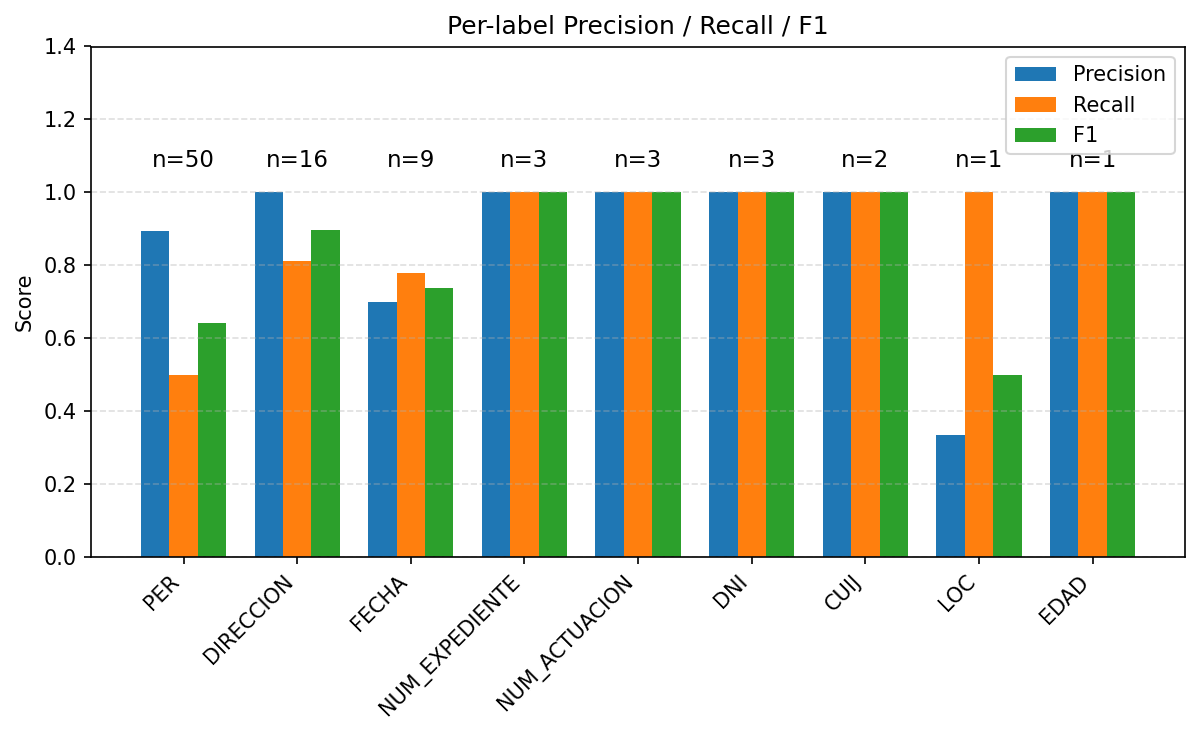

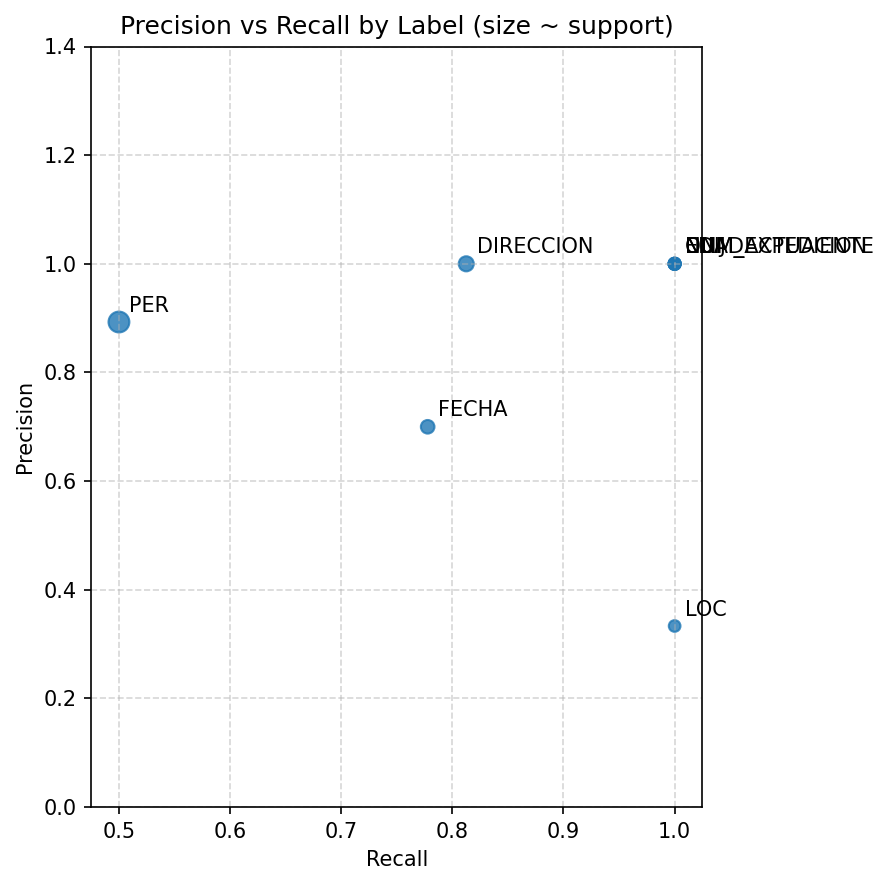

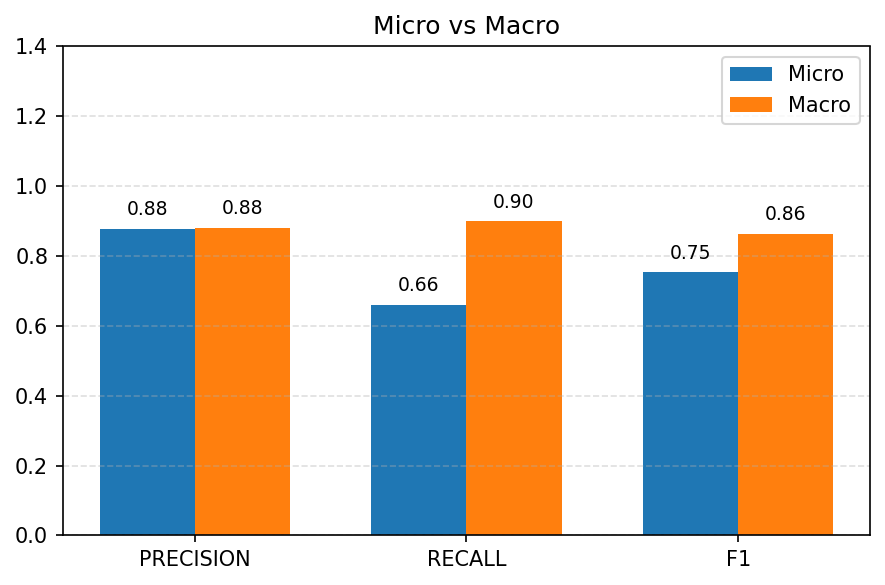

In [500]:
out = metrics_per_entity_by_span(df_main)
plot_per_label_bars(out, top=15, sort_by='support')
plot_pr_scatter(out, min_support=1, annotate_top=12)
plot_micro_macro(out)


In [482]:
out

{'per_label': {'NUM_EXPEDIENTE': {'precision': 0.0,
   'recall': 0.0,
   'f1': 0.0,
   'support': 13},
  'CUIJ': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 5},
  'NUM_ACTUACION': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 6},
  'PER': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 183},
  'FECHA': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 39},
  'DIRECCION': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 30},
  'LOC': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 18},
  'TELEFONO': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 17},
  'IP': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 4},
  'TEXTO_ANONIMIZAR': {'precision': 0.0,
   'recall': 0.0,
   'f1': 0.0,
   'support': 18},
  'EDAD': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 13},
  'DNI': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 31},
  'CORREO_ELECTRONICO': {'precision': 0.0,
   'recall': 0.0,
   'f1': 0.0,
   'supp

In [457]:
print(df.text.apply(lambda x: '\n'.join(x.split(' '))).iloc[0])
# medir cantidades de recall, f1, y precision por cada label

JUZGADO
DE
1RA
INSTANCIA
EN
LO
PENAL
CONTRAVENCIONAL
Y
DE
FALTAS
N°10
SECRETARIA
N°19


In [458]:
def norm(x):
    if x in (None, ""):
        return None
    if not isinstance(x, str):
        x = str(x)
    x = x.strip()            
    x = x.strip(",.;:")
    return x or None

def metrics_for_label(df, target='text'):
    tp, fp, fn = 0, 0, 0
    for i in range(len(df)):
        # aplicar eval a toda la columna 
        # agarrar los caracteres 'start_char' and 'end_char'
        # replicar .txt como dev.txt que tiene formato TEXTO, PREDICCION, VALIDACION
        try:
            val = eval(df.validation.iloc[i])[:]
        except:
            val = []
        try:
            pred = eval(df.prediction.iloc[i])[:]
        except:
            pred = []

        text_val  = val.get('attrs', {}).get('aymurai_alt_text', None) if val else None
        text_pred = pred.get('attrs', {}).get('aymurai_alt_text', None) if pred else None
        label_pred = pred.get('label', None) if pred else None
        label_val  = val.get('attrs', {}).get('aymurai_label', None) if val else None

        if target == 'text':
            pred_set = set(x for x in (text_pred,) if x not in (None, ""))
            val_set  = set(x for x in (text_val,)  if x not in (None, ""))
            
        elif target == 'label':
            pred_set = set(x for x in (label_pred,) if x not in (None, ""))
            val_set  = set(x for x in (label_val,)  if x not in (None, ""))

        elif target == 'both':

            pred_set = set(x for x in (text_pred, label_pred) if x not in (None, ""))
            val_set  = set(x for x in (text_val,  label_val)  if x not in (None, ""))

        else:
            raise ValueError("Target must be one of 'text', 'label', or 'both'")
        
        # contar solo si hay algún item real (evita TN de ambos vacíos)
        if len(pred_set) > 0 or len(val_set) > 0:
            print(pred_set, val_set)
            tp += len(pred_set & val_set)
            fp += len(pred_set - val_set)
            fn += len(val_set - pred_set)

    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (recall + precision) > 0 else 0

    return {'recall': recall, 'precision': precision, 'f1': f1}
metrics_for_label(df, target='text')

AttributeError: 'list' object has no attribute 'get'

In [ ]:
norm(val.get('attrs', {}).get('aymurai_alt_text', None) if val else None)

'IPP 108848/2024-0'

In [ ]:
metrics_for_label(df, target='label')

{'PER'} set()
{'PER'} {'PER'}
{'NUM_EXPEDIENTE'} {'NUM_EXPEDIENTE'}
{'NUM_ACTUACION'} {'NUM_ACTUACION'}
{'CUIJ'} {'CUIJ'}
{'PER'} set()
{'PER'} set()
{'PER'} {'PER'}
{'PER'} {'PER'}
{'PER'} {'PER'}
{'DIRECCION'} {'DIRECCION'}
{'PER'} {'PER'}
{'PER'} {'PER'}
{'NUM_ACTUACION'} {'NUM_ACTUACION'}
{'NUM_EXPEDIENTE'} {'NUM_EXPEDIENTE'}
{'CUIJ'} {'CUIJ'}
{'PER'} {'PER'}
{'NUM_ACTUACION'} {'NUM_ACTUACION'}
{'FECHA'} {'FECHA'}
{'FECHA'} {'FECHA'}
{'PER'} {'PER'}
{'PER'} {'PER'}
set() {'PER'}
set() {'PER'}
{'PER'} {'PER'}
{'PER'} {'PER'}
{'PER'} {'PER'}
{'PER'} {'PER'}
{'NUM_EXPEDIENTE'} {'NUM_EXPEDIENTE'}
{'PER'} {'PER'}
{'PER'} {'PER'}
{'PER'} {'PER'}
{'FECHA'} {'FECHA'}
{'DIRECCION'} {'DIRECCION'}
{'PER'} {'PER'}
{'PER'} {'PER'}
set() {'PER'}
{'DIRECCION'} {'DIRECCION'}
{'FECHA'} {'FECHA'}
{'PER'} {'PER'}
set() {'PER'}
{'DIRECCION'} {'DIRECCION'}
{'DIRECCION'} {'DIRECCION'}
{'PER'} {'PER'}
{'PER'} {'PER'}
set() {'PER'}
set() {'PER'}
{'FECHA'} {'FECHA'}
{'PER'} {'PER'}
{'PER'} {'PER'}
{'DIRECC

{'recall': 0.9315789473684211,
 'precision': 0.9779005524861878,
 'f1': 0.954177897574124}

In [ ]:
for i in range(50):
    try:
        val = eval(df.validation.iloc[i])[0]
    except:
        val = []
    try:
        pred = eval(df.prediction.iloc[i])[0]
    except:
        pred = []

    text_val  = val.get('attrs', {}).get('aymurai_alt_text', None) if val else None
    text_pred = pred.get('attrs', {}).get('aymurai_alt_text', None) if pred else None
    label_pred = pred.get('label', None) if pred else None
    label_val  = val.get('attrs', {}).get('aymurai_label', None) if val else None
    print(text_val, text_pred, label_val, label_pred)


None None None None
None None None None
None None None None
IPP 108848/2024-0 IPP 108848/2024-0 NUM_EXPEDIENTE NUM_EXPEDIENTE
IPP J-01-00108848-9/2024-0 IPP J-01-00108848-9/2024-0 CUIJ CUIJ
659483/2025 659483/2025 NUM_ACTUACION NUM_ACTUACION
AYALA, FERNANDO GABRIEL AYALA, FERNANDO GABRIEL PER PER
None None None None
None None None None
23 de abril de 2025 23 de abril de 2025 FECHA FECHA
None None None None
None None None None
None None None None
None None None None
None None None None
None None None None
None None None None
None None None None
None None None None
None None None None
None None None None
None None None None
None None None None
None None None None
None None None None
188309393 188309393 TEXTO_ANONIMIZAR TEXTO_ANONIMIZAR
29 de abril de 2025 29 de abril de 2025 FECHA FECHA
None None None None
None None None None
Chacabuco 151 Chacabuco 151 DIRECCION DIRECCION
18 de mayo del año 2024 18 de mayo del año 2024 FECHA FECHA
None None None None
23 de junio del año 2024 23 de junio